# Humpback Whale Identification — Triplet Loss Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## Setup

In [1]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_metric_dataloaders,
 )
from models import build_model
from training import train
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX PRO 4000 Blackwell


/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


## Triplet Loss Training

**Triplet Loss** (Schroff et al., FaceNet, CVPR 2015 — course slides 21–24) directly
optimizes embedding distances. For each triplet (anchor, positive, negative):

$$L(A, P, N) = \max\{0,\ \|f(A) - f(P)\|^2 - \|f(A) - f(N)\|^2 + m\}$$

Key implementation details:
- **Semi-hard negative mining**: negatives that are farther than the positive but within
  the margin — provides the most useful gradient signal.
- **Limitation**: classes with only 1 image cannot participate (no positive pair possible).
  This significantly reduces the usable training set — a real limitation worth discussing.

The model uses `head_type="none"` — no classifier, only the L2-normalized embedding.


In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="triplet_effnetb5",
    description="Triplet loss with semi-hard mining, open-set random sampling",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="none",          # ← No classifier, embedding-only

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=3,
    freeze_bn=True,
    epochs=35,
    batch_size=24,            # Open-set random batch size
    accumulation_steps=2,      
    use_amp=True,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="triplet",
    triplet_margin=0.3,
    triplet_mining="semi_hard",
    use_class_weights=False,   # Not applicable for triplet loss

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="known_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
 )

print("Triplet config:")
print(config.summary())


Triplet config:
efficientnet_b5 | 456px | triplet(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=24×2 | head=none | triplet(m=0.3,semi_hard)


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [4]:
TRAINING_ENABLED = False
EXPERIMENT_ID = "20260527_195128_triplet_effnetb5_e7fa63cf"

if TRAINING_ENABLED:
    manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    # manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

Skipping training


## Training analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


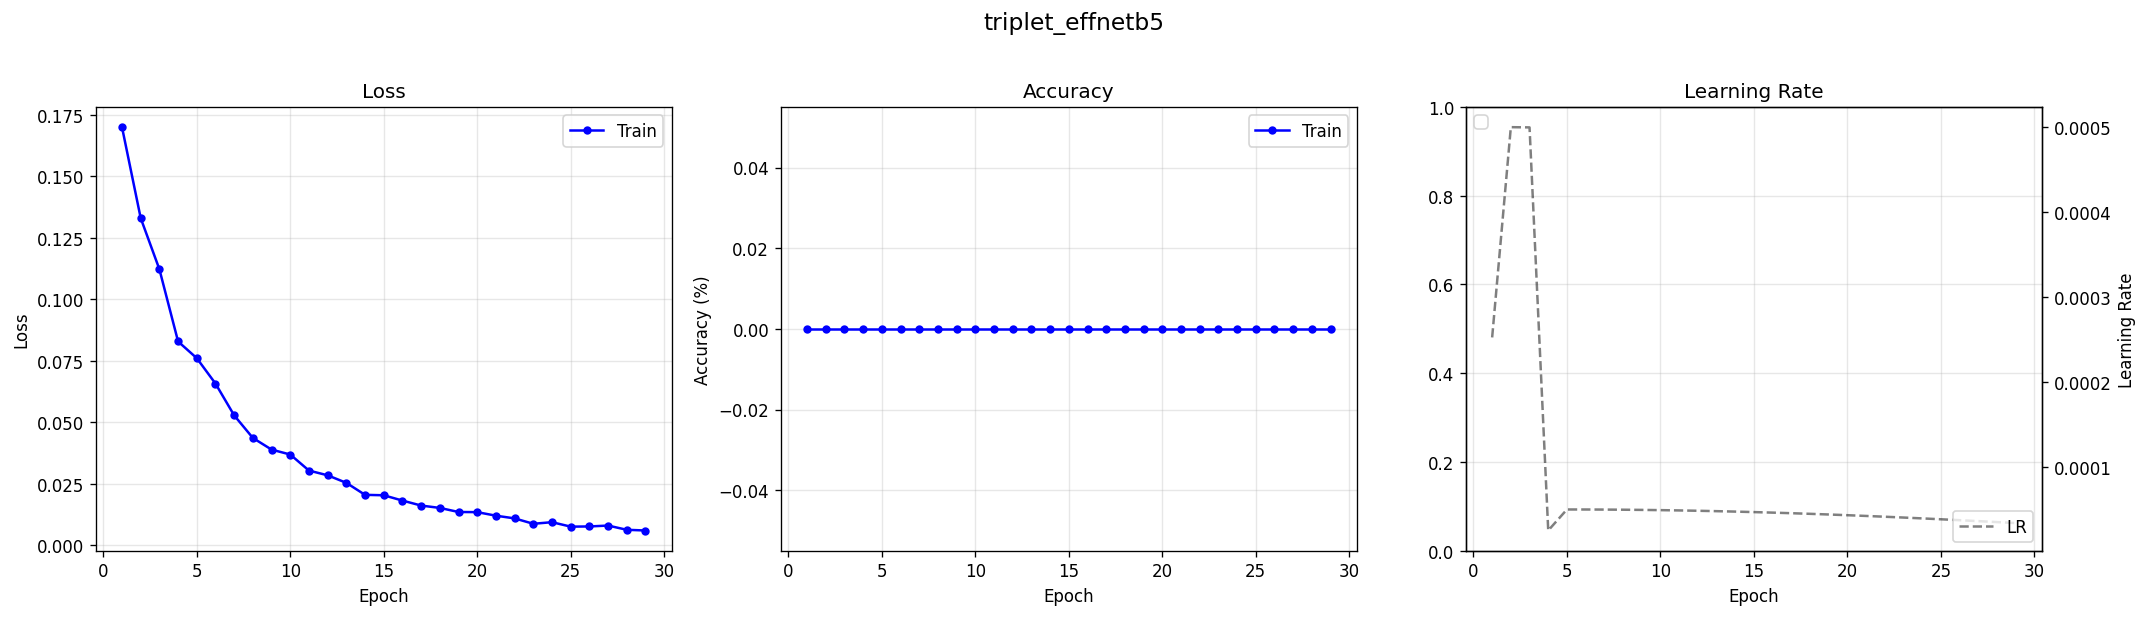

In [5]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [6]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "known_recall@1", 
            "known_recall@5", "mean_known_conf", "mean_new_whale_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key or "recall" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 0.0059
  known_recall@1                : 70.20%
  known_recall@5                : 79.80%
  mean_known_conf               : 0.9051
  mean_new_whale_conf           : 0.8852


## Evaluate best model

In [7]:
from final_evaluation import evaluate_base_metrics, get_classifier_predictions, get_retrieval_predictions

# Load best model
config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
model = build_model(config, data["num_classes"], device)
state = torch.load("experiments/" + EXPERIMENT_ID + "/checkpoints/best.pth", map_location=device, weights_only=False)
model_state = state.get("model_state_dict", state)
model.load_state_dict(model_state)
model.eval()

# Run evaluation
#criterion = build_loss(config, data["class_counts"], device)
eval_config, data = get_eval_config_and_data()
gallery_loader, query_loader = build_retrieval_eval_loaders(eval_config, data)
scores, predictions, labels = get_retrieval_predictions(model, gallery_loader, query_loader, device, 5)
val_metrics = evaluate_base_metrics(scores, predictions, labels)

print("\nBest model validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]


Best model validation metrics:
  known_recall@1                : 0.7020
  known_recall@5                : 0.8165
  mean_known_conf               : 0.9119
  mean_new_whale_conf           : 0.8965


## Embedding quality

  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

t-SNE: 224 points, 10 classes (min 5/class)


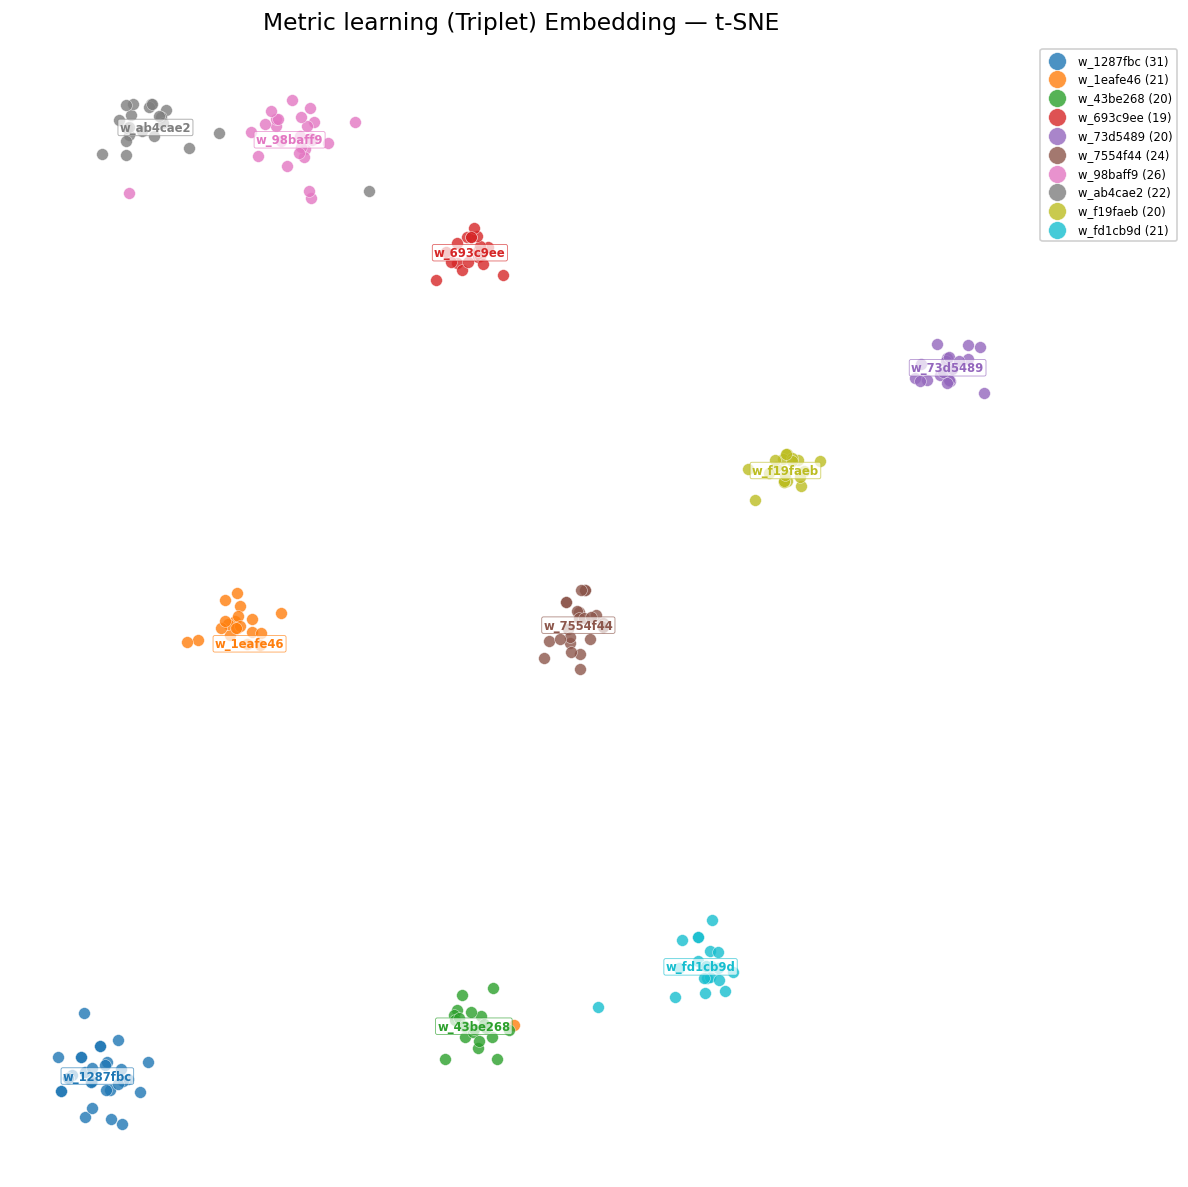

  Perplexity used: 28 | KL divergence: 0.10


In [9]:
# ── Usage ────────────────────────────────────────────────────────────────
# Combine train + val loaders to get enough points per class for visible clusters.
# This is purely for visualization — evaluation metrics stay on val only.
from visualization import plot_embedding_tsne

if model is not None:
    plot_embedding_tsne(
        model, query_loader, data, device,
        title="Metric learning (Triplet) Embedding — t-SNE",
        top_k_classes=10,
        min_samples_per_class=5,
        combine_loaders=[gallery_loader],
    )